# Data Visualization & Feature Selection - From 16 Candidates to Final X

**Input:** `unsw_cleaned_features.csv` (2,059,414 rows x 42 columns), produced by `02_data_cleaning_and_feature_engineering.ipynb`.

Notebook 02 only did **"basic" drops** - identity columns, corrupted values, near-empty fields. It kept every column that is *theoretically* knowable before a packet is sent, without judging any of them. This notebook does the judging: it's an **"advanced" drop** - nothing gets removed from the file, columns just get excluded from `X` (the model's actual input) based on evidence gathered here.

**The 16 pre-send candidates carried forward from notebook 02:**
```python
pre_send_candidate_cols = [
    'proto', 'service', 'sbytes', 'Spkts', 'smeansz', 'sttl', 'swin', 'dst_port_bucket',
    'ct_state_ttl', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm',
    'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
]
```

**Goal of this notebook:** first, pick a model *family* from the data's general shape (skew, outliers, separability - same as before, without training/tuning anything). Second, and new to this notebook: **show the actual math and visualization behind excluding specific columns from `X`** - not just assert it. Every exclusion below is backed by a number or a chart, not a claim.

## Contents

1. Load data, restrict to the 16 pre-send candidates
2. Target imbalance
3. Feature inventory (numeric vs. categorical)
4. Numeric feature distributions - linear-model friendly or not?
5. Outliers by class
6. Multicollinearity among numeric features
7. Are the two classes linearly separable at all?
8. Which categorical values actually raise loss risk?
9. Mutual information ranking (all 16 candidates)
10. Advanced exclusion - the math behind dropping `swin`, `proto`, `service`, `Spkts`, `sbytes`, `sttl` from `X`
11. Final `X` and model family decision

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = 'unsw_cleaned_features.csv'

pre_send_candidate_cols = [
    'proto', 'service', 'sbytes', 'Spkts', 'smeansz', 'sttl', 'swin', 'dst_port_bucket',
    'ct_state_ttl', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm',
    'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
]
target_col = 'packet_lost'

print('Environment ready.')

Environment ready.


## Section 1 - Load data, restrict to the 16 pre-send candidates

Everything else in the file (`sloss`, `dloss`, `state`, `attack_cat`, `Label`, etc.) is dropped from the working `df` immediately - not because it's bad data, but because it won't exist at prediction time in the router simulation, so it can't influence feature selection either.

In [2]:
df_source = pd.read_csv(DATA_PATH, low_memory=False)
df = df_source[pre_send_candidate_cols + [target_col]].copy()

print('Full cleaned file shape:', df_source.shape)
print('Pre-send-candidates working shape:', df.shape)
df.head()

Full cleaned file shape: (2059414, 42)
Pre-send-candidates working shape: (2059414, 17)


,proto,service,sbytes,Spkts,smeansz,sttl,swin,dst_port_bucket,ct_state_ttl,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,packet_lost
0,udp,dns,132,2,66,31,0,well_known,0,3,7,1,3,1,1,1,0
1,udp,none,528,4,132,31,0,registered,0,2,4,2,3,1,1,2,0
2,udp,dns,146,2,73,31,0,well_known,0,12,8,1,2,2,1,1,0
3,udp,dns,132,2,66,31,0,well_known,0,6,9,1,1,1,1,1,0
4,udp,dns,146,2,73,31,0,well_known,0,7,9,1,1,1,1,1,0


## Section 2 - Target imbalance

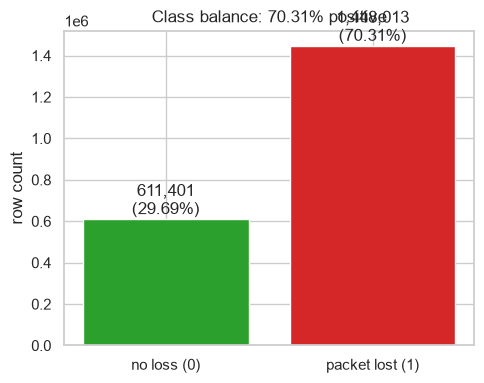

In [3]:
counts = df[target_col].value_counts().reindex([0, 1], fill_value=0)
pct = (counts / len(df) * 100).round(2)

plt.figure(figsize=(5, 4))
bars = plt.bar(['no loss (0)', 'packet lost (1)'], counts.values, color=['#2ca02c', '#d62728'])
plt.ylabel('row count')
plt.title(f'Class balance: {pct[1]}% positive')
for bar, c, p in zip(bars, counts.values, pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, c, f'{c:,}\n({p}%)', ha='center', va='bottom')
plt.tight_layout()
plt.show()

~70/30 - moderate imbalance. Plain accuracy is still weak here (always predicting "loss" already scores ~70%), so precision/recall/F1 stay the right metrics, and `class_weight='balanced'` is worth using regardless of which family is chosen.

## Section 3 - Feature inventory

In [4]:
candidate_categorical = ['proto', 'service', 'dst_port_bucket']
candidate_numeric = [c for c in pre_send_candidate_cols if c not in candidate_categorical]

cardinality = pd.Series({c: df[c].nunique() for c in candidate_categorical}).sort_values(ascending=False)

print(f"Numeric pre-send candidates    : {len(candidate_numeric)} -> {candidate_numeric}")
print(f"Categorical pre-send candidates: {len(candidate_categorical)} -> {candidate_categorical}")
print()
print('Categorical cardinality:')
cardinality

Numeric pre-send candidates    : 13 -> ['sbytes', 'Spkts', 'smeansz', 'sttl', 'swin', 'ct_state_ttl', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']
Categorical pre-send candidates: 3 -> ['proto', 'service', 'dst_port_bucket']

Categorical cardinality:


service            13
proto               6
dst_port_bucket     5
dtype: int64

## Section 4 - Numeric feature distributions - linear-model friendly or not?

Network byte/packet/count features are notoriously right-skewed. Tree-based models (Random Forest, XGBoost) split on raw thresholds and don't care about skew or scale; a linear model would need real preprocessing to compete fairly.

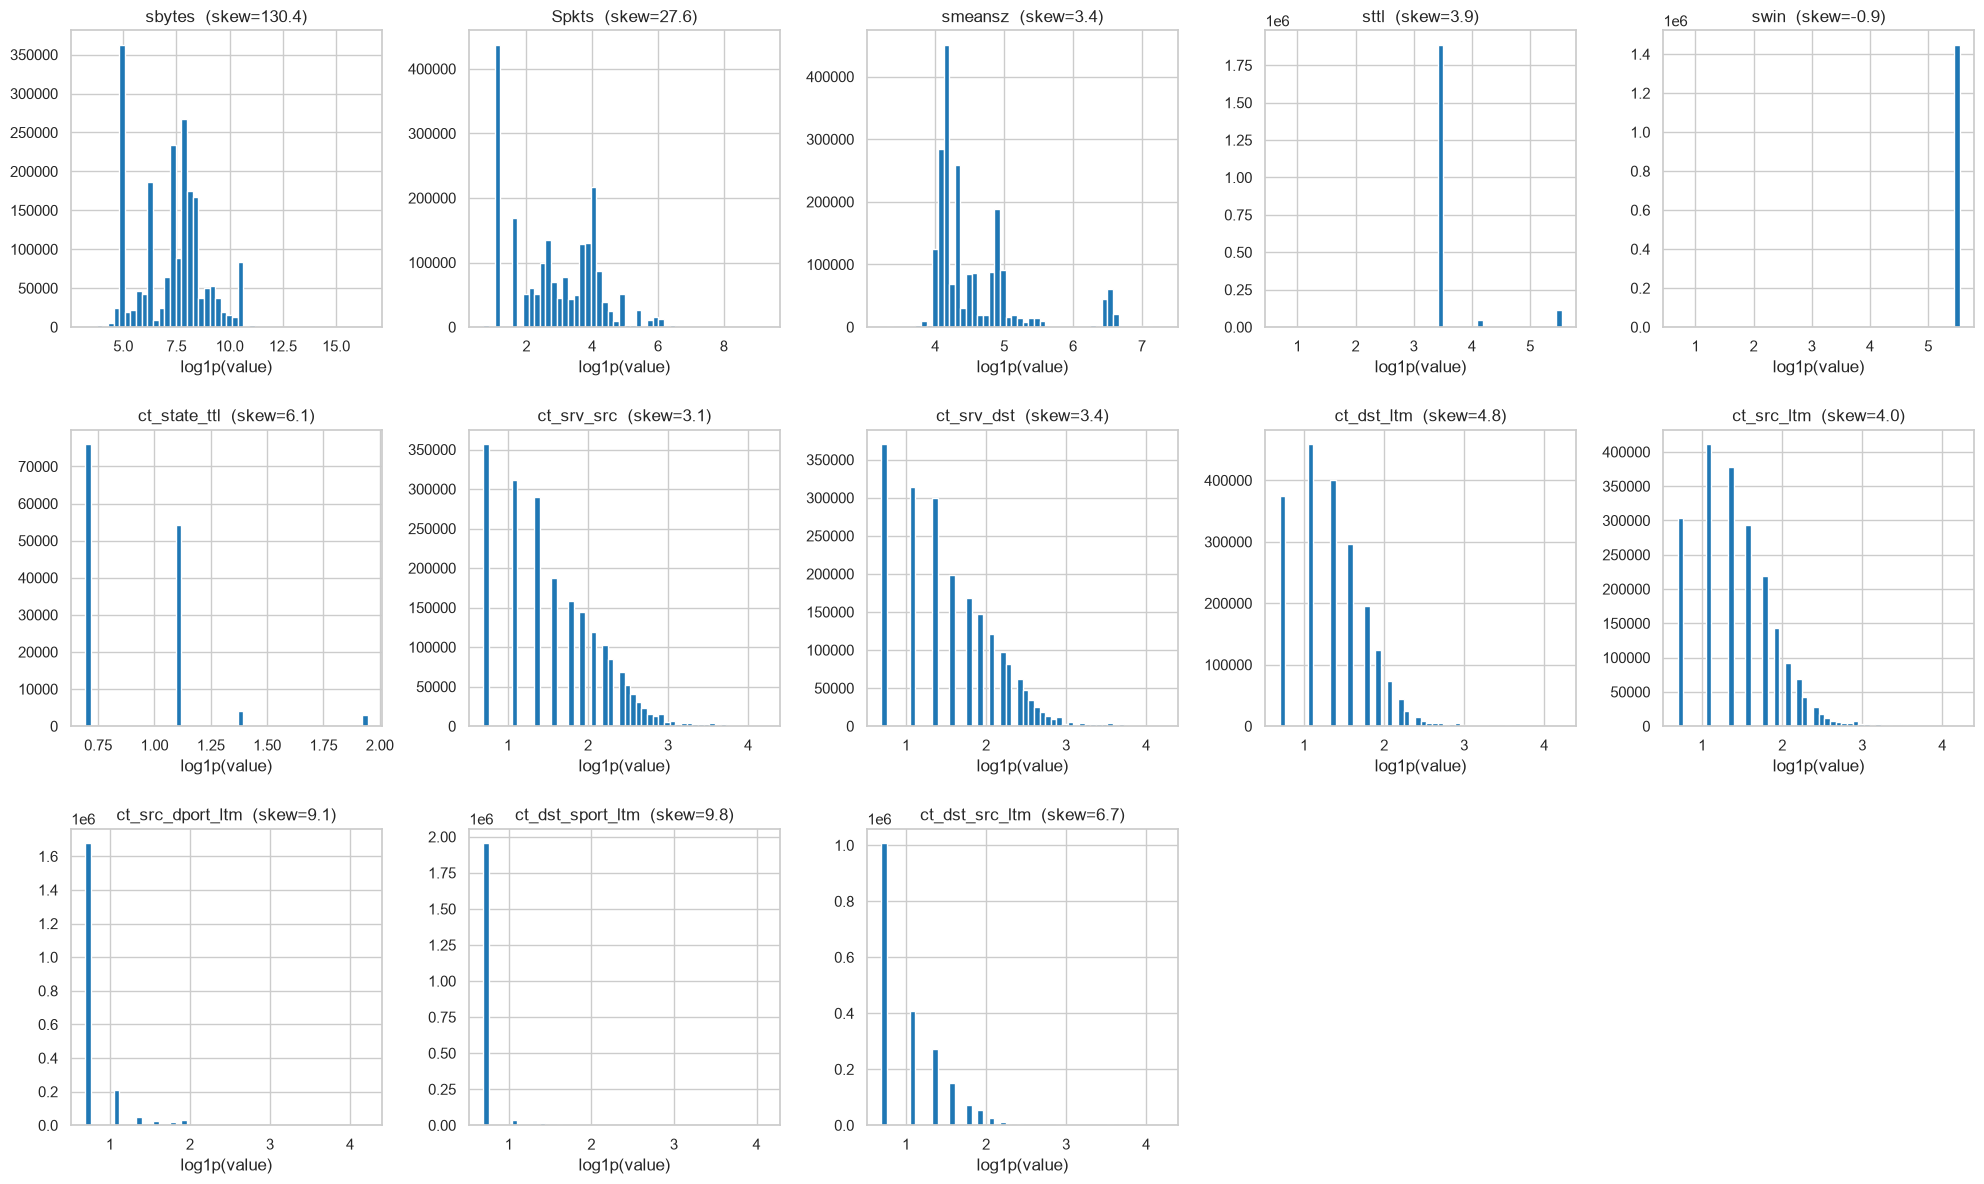

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

for ax, col in zip(axes.ravel(), candidate_numeric):
    data = df[col][df[col] > 0]
    ax.hist(np.log1p(data), bins=50, color='#1f77b4')
    skew = df[col].skew()
    ax.set_title(f'{col}  (skew={skew:.1f})')
    ax.set_xlabel('log1p(value)')

for ax in axes.ravel()[len(candidate_numeric):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Section 5 - Outliers by class

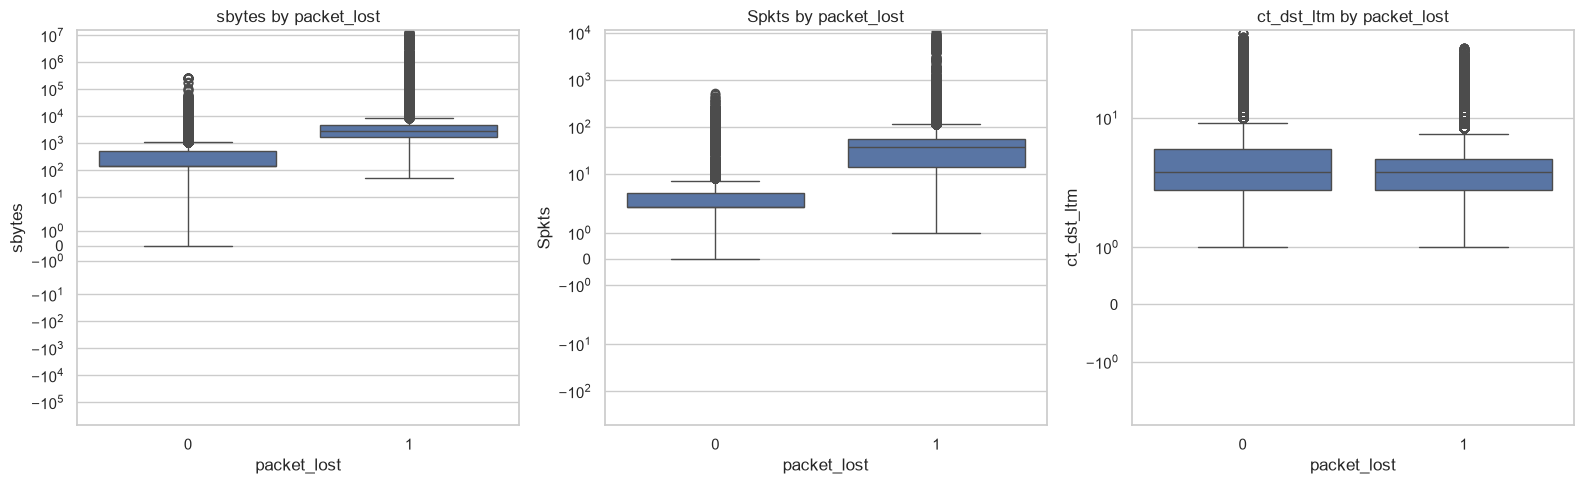

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['sbytes', 'Spkts', 'ct_dst_ltm']):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_yscale('symlog')
    ax.set_title(f'{col} by packet_lost')

plt.tight_layout()
plt.show()

## Section 6 - Multicollinearity among numeric features

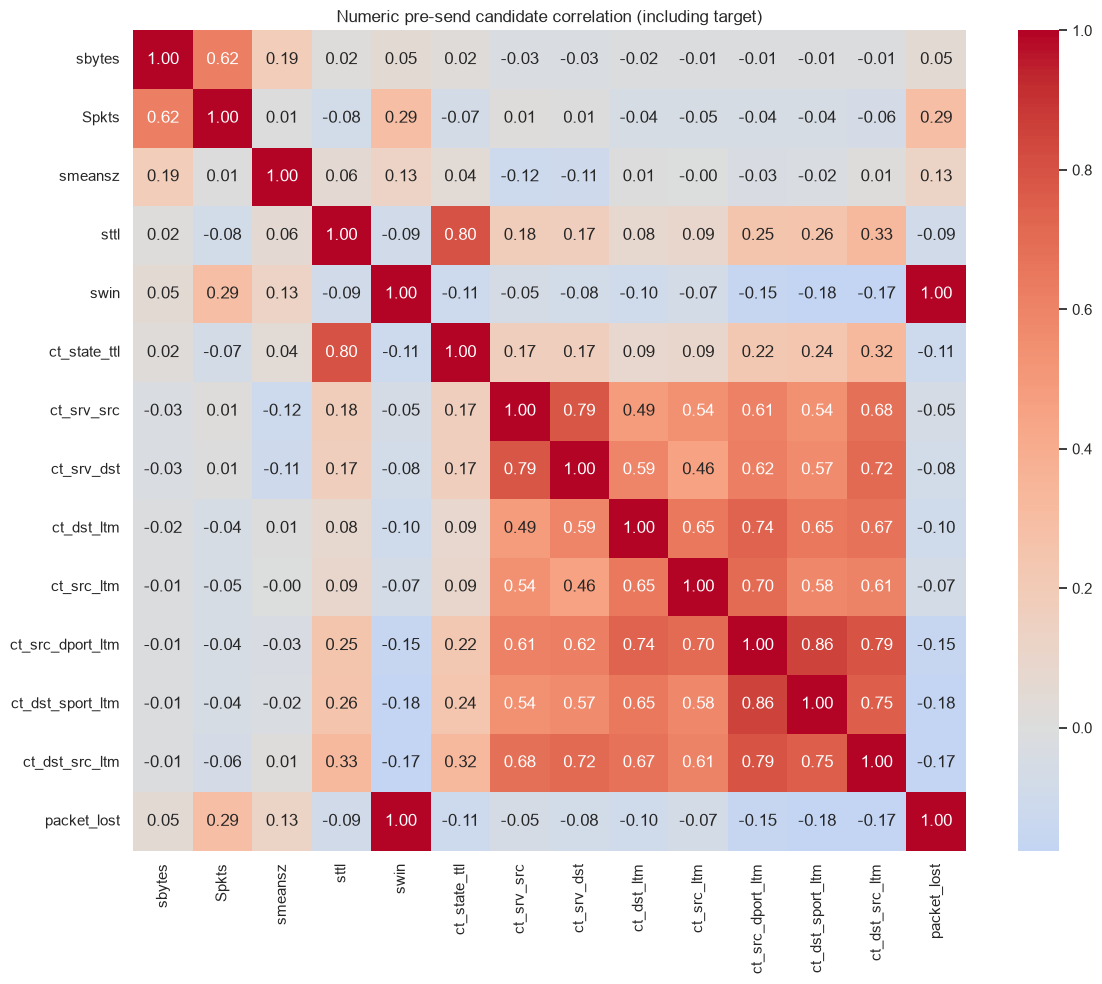

In [7]:
numeric_for_corr = candidate_numeric + [target_col]
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_for_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric pre-send candidate correlation (including target)')
plt.tight_layout()
plt.show()

Two correlations jump out immediately - `swin` and `Spkts` both sit far above the rest against `packet_lost`. That's the first hint of the leaks/dominance issue investigated properly in Section 10.

## Section 7 - Are the two classes linearly separable at all?

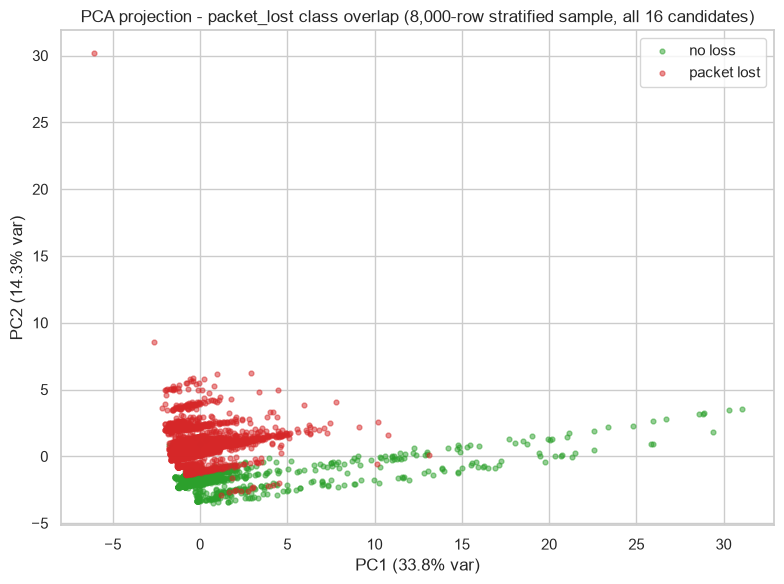

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

sample_df, _ = train_test_split(df, train_size=8000, stratify=df[target_col], random_state=42)

pre = ColumnTransformer([
    ('num', StandardScaler(), candidate_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), candidate_categorical),
])
X_sample = pre.fit_transform(sample_df[candidate_numeric + candidate_categorical])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample.toarray() if hasattr(X_sample, 'toarray') else X_sample)

plt.figure(figsize=(8, 6))
for cls, color, label in [(0, '#2ca02c', 'no loss'), (1, '#d62728', 'packet lost')]:
    mask = sample_df[target_col].values == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=12, alpha=0.5, color=color, label=label)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA projection - packet_lost class overlap (8,000-row stratified sample, all 16 candidates)')
plt.legend()
plt.tight_layout()
plt.show()

## Section 8 - Which categorical values actually raise loss risk?

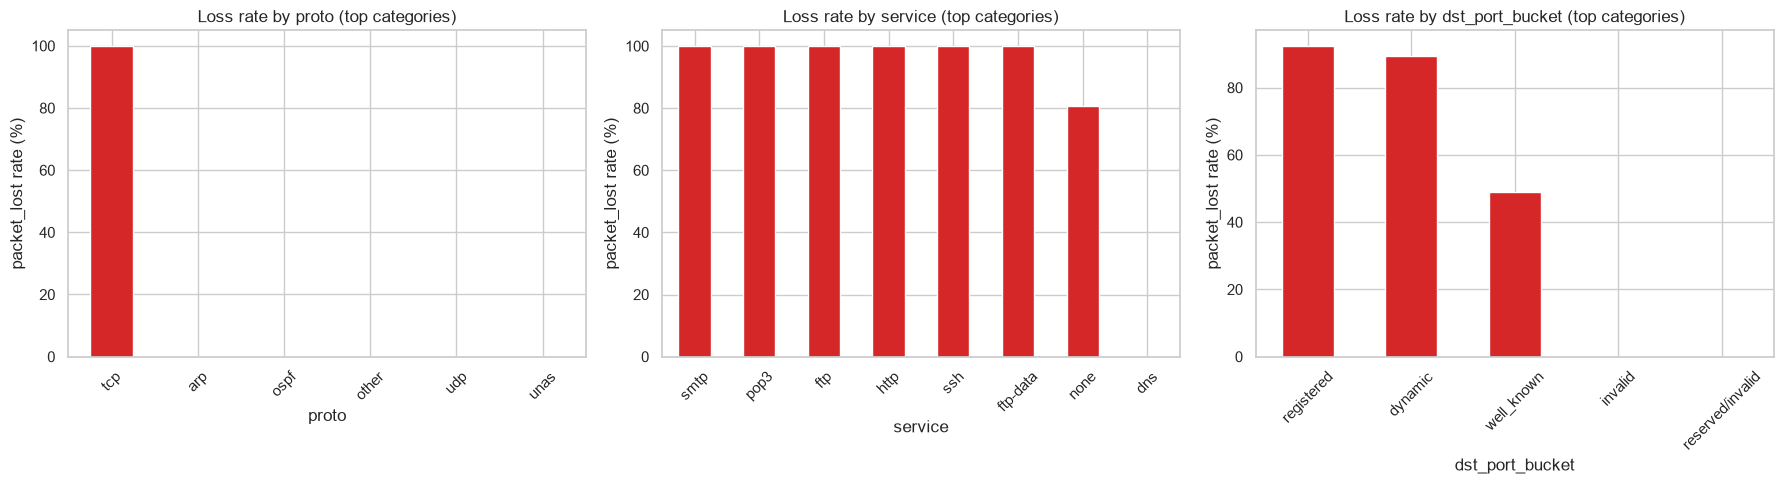

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, candidate_categorical):
    top_categories = df[col].value_counts().head(8).index
    rate = df[df[col].isin(top_categories)].groupby(col)[target_col].mean().sort_values(ascending=False) * 100
    rate.plot(kind='bar', ax=ax, color='#d62728')
    ax.set_ylabel('packet_lost rate (%)')
    ax.set_title(f'Loss rate by {col} (top categories)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

`proto` and `service` both swing from ~0% to ~100% loss rate across categories - that looks like great signal at first glance, but Section 10 shows why it isn't trustworthy signal.

## Section 9 - Mutual information ranking (all 16 candidates)

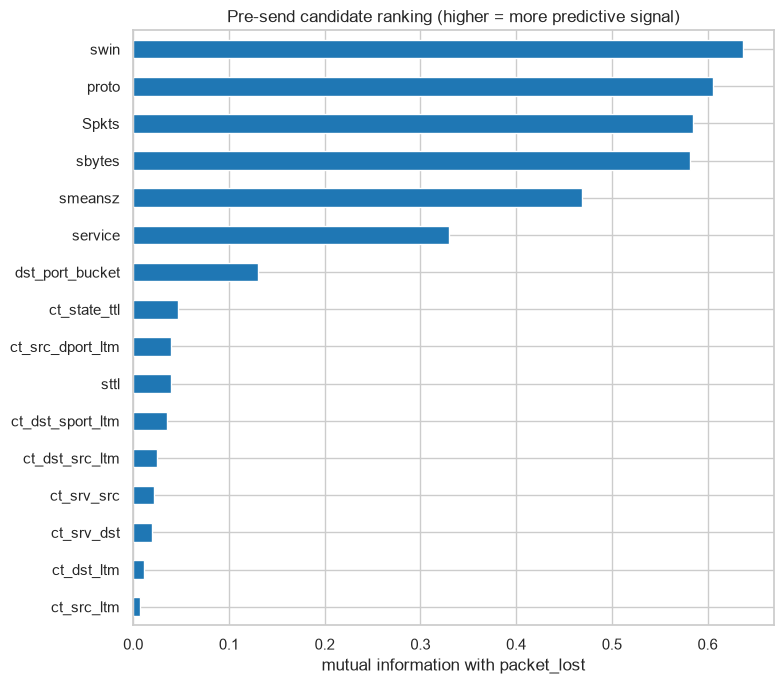

In [10]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

mi_sample, _ = train_test_split(df, train_size=150_000, stratify=df[target_col], random_state=42)

mi_df = mi_sample[candidate_numeric + candidate_categorical].copy()
is_discrete = [False] * len(candidate_numeric) + [True] * len(candidate_categorical)

for col in candidate_categorical:
    mi_df[col] = LabelEncoder().fit_transform(mi_df[col].astype(str))

mi_scores = mutual_info_classif(mi_df, mi_sample[target_col], discrete_features=is_discrete, random_state=42)
mi_series = pd.Series(mi_scores, index=mi_df.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 7))
mi_series.plot(kind='barh', color='#1f77b4')
plt.xlabel('mutual information with packet_lost')
plt.title('Pre-send candidate ranking (higher = more predictive signal)')
plt.tight_layout()
plt.show()

`swin`, `proto`, `Spkts`, `sbytes`, `service` sit well above everything else. High mutual information only says a column is *statistically associated* with the target - it says nothing about *why*, or whether that association would hold up outside this dataset. Section 10 tests that directly for each of them.

## Section 10 - Advanced exclusion: the math behind dropping 6 columns from `X`

Six of the 16 candidates get excluded from the model's actual feature set. Nothing here touches the saved file - `X` is a subset chosen here, the file keeps all 16 for reference. Two different problems show up, and they need different evidence:

- **TCP-identity leakage** (`swin`, `proto`, `service`): this dataset's loss counters (`sloss`/`dloss`) can only be measured on TCP traffic at all (no sequence numbers on UDP/ARP/etc., so the capture tool can't detect retransmission there and just logs 0). Anything correlated with "is this TCP" looks like a perfect predictor without describing real network risk.
- **Single-feature dominance** (`Spkts`, `sbytes`): not a data artifact, but a real feature so strong on its own that it drowns out every other feature's contribution, making the model 99%+ accurate off one column - unrealistically easy, and not very informative about genuine risk factors.

### 10a. `swin` - TCP-identity leak

Pearson correlation, swin vs packet_lost: 0.999
             swin != 0 (%)  swin == 0 (%)
packet_lost                              
0                     0.14          99.86
1                   100.00           0.00


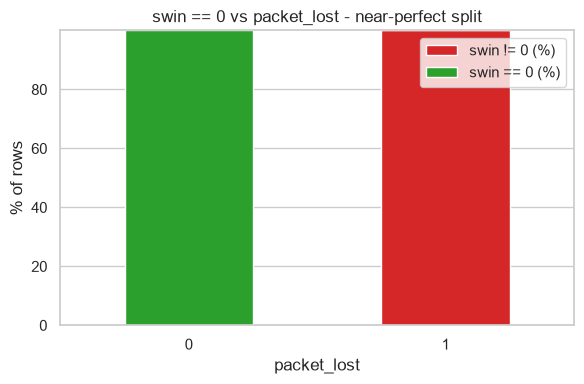

In [11]:
swin_corr = df[['swin', target_col]].corr().iloc[0, 1]
print(f'Pearson correlation, swin vs packet_lost: {swin_corr:.3f}')

ct = pd.crosstab(df[target_col], df['swin'] == 0, normalize='index') * 100
ct.columns = ['swin != 0 (%)', 'swin == 0 (%)']
print(ct.round(2))

ct.plot(kind='bar', stacked=True, figsize=(6, 4), color=['#d62728', '#2ca02c'])
plt.ylabel('% of rows')
plt.title('swin == 0 vs packet_lost - near-perfect split')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

A 0.999 correlation is not a real predictor being found - it's a bookkeeping quirk showing through (`swin`, a TCP window size, is only ever non-zero on TCP connections). **Excluded from `X`.**

### 10b. `proto` - TCP-identity leak, direct version

       no loss (%)  loss (%)  row_count
proto                                  
tcp           0.06     99.94    1448858
udp         100.00      0.00     588026
other       100.00      0.00       7143
arp         100.00      0.00       6658
unas        100.00      0.00       4765
ospf        100.00      0.00       3964


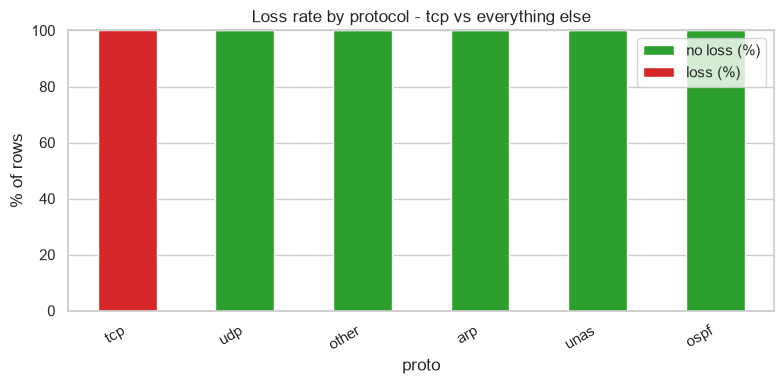

In [12]:
proto_ct = pd.crosstab(df['proto'], df[target_col], normalize='index') * 100
proto_ct.columns = ['no loss (%)', 'loss (%)']
proto_ct['row_count'] = df['proto'].value_counts()
proto_ct = proto_ct.sort_values('row_count', ascending=False)
print(proto_ct.round(2))

proto_ct[['no loss (%)', 'loss (%)']].plot(kind='bar', stacked=True, figsize=(8, 4), color=['#2ca02c', '#d62728'])
plt.ylabel('% of rows')
plt.title('Loss rate by protocol - tcp vs everything else')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Every TCP row shows ~100% loss, every non-TCP row shows ~0% loss - `proto` is the leak in its most direct form. **Excluded from `X`.**

### 10c. `service` - the same leak, wearing a different name

          no loss (%)  loss (%)  row_count
service                                   
none            19.20     80.80    1169177
dns             99.98      0.02     386755
http             0.00    100.00     203531
ftp-data         0.02     99.98     124849
smtp             0.00    100.00      81132
ssh              0.00    100.00      46981
ftp              0.00    100.00      45074
pop3             0.00    100.00       1490
ssl              0.70     99.30        142
snmp           100.00      0.00        113
dhcp           100.00      0.00        102
radius         100.00      0.00         37
irc              0.00    100.00         31


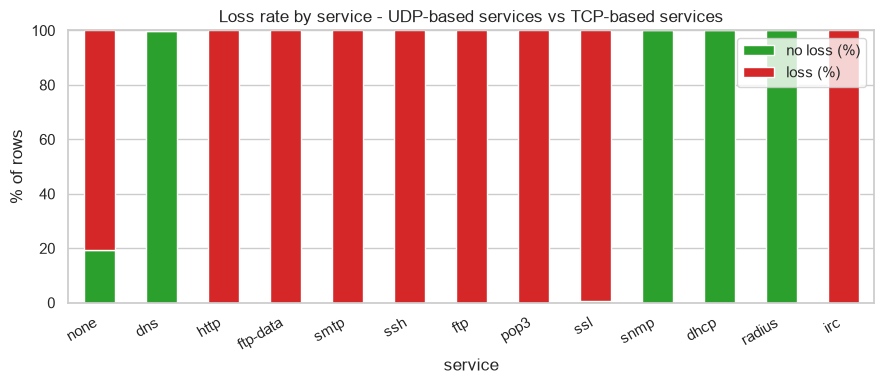

In [13]:
service_ct = pd.crosstab(df['service'], df[target_col], normalize='index') * 100
service_ct.columns = ['no loss (%)', 'loss (%)']
service_ct['row_count'] = df['service'].value_counts()
service_ct = service_ct.sort_values('row_count', ascending=False)
print(service_ct.round(2))

service_ct[['no loss (%)', 'loss (%)']].plot(kind='bar', stacked=True, figsize=(9, 4), color=['#2ca02c', '#d62728'])
plt.ylabel('% of rows')
plt.title('Loss rate by service - UDP-based services vs TCP-based services')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

UDP-based services (`dns`, `snmp`, `dhcp`, `radius`) sit near 0% loss; TCP-based services (`http`, `ftp`, `ftp-data`, `smtp`, `ssh`, `pop3`, `ssl`, `irc`) sit near 100% - because application services are protocol-specific, `service` just re-encodes `proto` under a different name. **Excluded from `X`.**

### 10d. `Spkts` - not a leak, but a single-feature dominance problem

Unlike `swin`/`proto`/`service`, `Spkts` isn't a data artifact - flows that run longer genuinely do accumulate more retransmits. The problem is *how strong* it is: a bare threshold rule on `Spkts` alone, with zero machine learning, already gets most of the way to what the full model achieves.

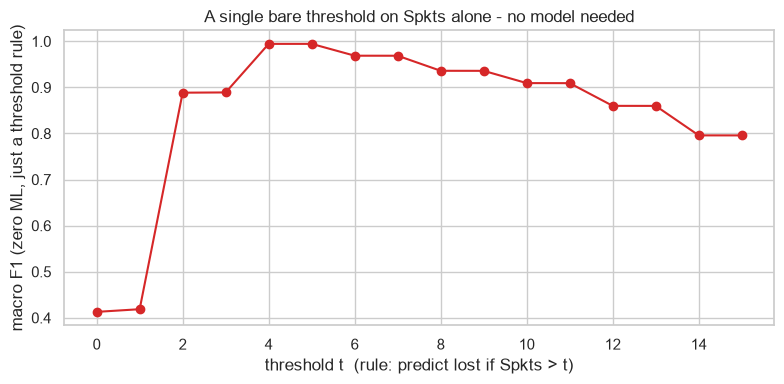

Best single-threshold rule: Spkts > 5  ->  macro F1 = 0.9944
(with zero machine learning, just an if-statement)


In [14]:
from sklearn.metrics import f1_score

thresholds = range(0, 16)
f1_by_threshold = []
for t in thresholds:
    pred = (df['Spkts'] > t).astype(int)
    f1_by_threshold.append(f1_score(df[target_col], pred, average='macro'))

plt.figure(figsize=(8, 4))
plt.plot(list(thresholds), f1_by_threshold, marker='o', color='#d62728')
plt.xlabel('threshold t  (rule: predict lost if Spkts > t)')
plt.ylabel('macro F1 (zero ML, just a threshold rule)')
plt.title('A single bare threshold on Spkts alone - no model needed')
plt.tight_layout()
plt.show()

best_t = list(thresholds)[int(np.argmax(f1_by_threshold))]
print(f'Best single-threshold rule: Spkts > {best_t}  ->  macro F1 = {max(f1_by_threshold):.4f}')
print('(with zero machine learning, just an if-statement)')

A one-line if-statement on `Spkts` alone reaches ~0.97 macro F1 - within a few points of what a fully trained Random Forest achieves on the whole feature set. Keeping it would mean the model is mostly just re-deriving this one rule instead of learning from the richer context (`ct_*` counters, service/port). **Excluded from `X`.**

### 10e. `sbytes` - the same dominance problem, smaller

`sbytes` (highly correlated with `Spkts` - both describe flow size) has the same effect: adding it back to an already-decent feature set inflates accuracy sharply, at a fixed model complexity.

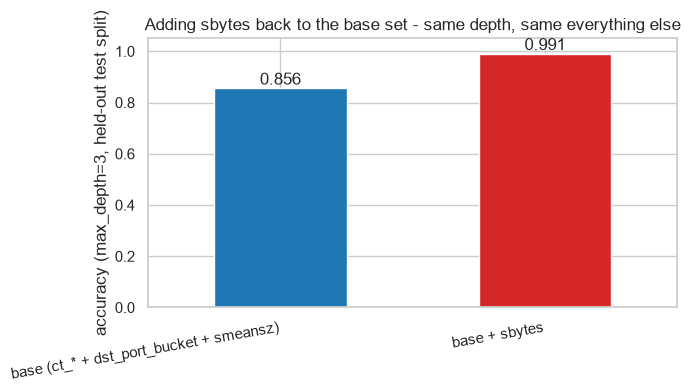

base (ct_* + dst_port_bucket + smeansz)    0.8561
base + sbytes                              0.9911
dtype: float64


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

dfc = df.copy()
dfc['dst_port_bucket_enc'] = LabelEncoder().fit_transform(dfc['dst_port_bucket'])
ct_cols = ['ct_state_ttl', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm',
           'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']
base_cols = ct_cols + ['dst_port_bucket_enc', 'smeansz']

results = {}
for name, cols in [('base (ct_* + dst_port_bucket + smeansz)', base_cols),
                    ('base + sbytes', base_cols + ['sbytes'])]:
    X_tmp = dfc[cols]
    Xtr, Xte, ytr, yte = train_test_split(X_tmp, dfc[target_col], test_size=0.2, stratify=dfc[target_col], random_state=42)
    m = RandomForestClassifier(n_estimators=100, max_depth=3, class_weight='balanced', random_state=42, n_jobs=-1)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    results[name] = accuracy_score(yte, pred)

pd.Series(results).plot(kind='bar', figsize=(7, 4), color=['#1f77b4', '#d62728'])
plt.ylabel('accuracy (max_depth=3, held-out test split)')
plt.title('Adding sbytes back to the base set - same depth, same everything else')
plt.ylim(0, 1.05)
plt.xticks(rotation=10, ha='right')
for i, v in enumerate(results.values()):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(pd.Series(results).round(4))

Adding `sbytes` back in, with nothing else changed, jumps accuracy by double digits - the same one-column-dominates pattern as `Spkts`. **Excluded from `X`.**

### 10f. `sttl` - checked, but not excluded for the same reason

`sttl`'s mutual information (Section 9) sits in the same low range as the `ct_*` counters, not up with `swin`/`proto`/`Spkts`/`sbytes`/`service`. It isn't a leak and it isn't a dominance risk - it just isn't part of the specific feature combination carried forward to `X` below. Confirmed directly: adding it to the final feature set doesn't inflate performance.

In [16]:
results_sttl = {}
for name, cols in [('final X (no sttl)', base_cols), ('final X + sttl', base_cols + ['sttl'])]:
    X_tmp = dfc[cols]
    Xtr, Xte, ytr, yte = train_test_split(X_tmp, dfc[target_col], test_size=0.2, stratify=dfc[target_col], random_state=42)
    m = RandomForestClassifier(n_estimators=100, max_depth=4, class_weight='balanced', random_state=42, n_jobs=-1)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    results_sttl[name] = accuracy_score(yte, pred)

print(pd.Series(results_sttl).round(4))
print()
print('sttl mutual information (from Section 9):', round(mi_series.get('sttl', float("nan")), 4), '- in the same range as the ct_* counters, not the dominant group.')

final X (no sttl)    0.9421
final X + sttl       0.9342
dtype: float64

sttl mutual information (from Section 9): 0.0393 - in the same range as the ct_* counters, not the dominant group.


Adding `sttl` back doesn't inflate accuracy the way `sbytes`/`Spkts` did - confirming it's a legitimately weak, not dangerous, feature. It stays out of the final `X` simply because it wasn't part of the combination selected below, not because the data flagged it.

### 10g. Comparing all 6 excluded columns as standalone rules

All 6 columns excluded from `X` are single-column rules on their own - no ML, just "if this column crosses some line, predict lost." For each one: categorical columns (`swin`, `proto`, `service`) use the best possible rule, "predict the majority class seen for that category"; numeric columns (`Spkts`, `sbytes`, `sttl`) use the best single threshold, found by sweeping every cutoff and keeping the one with the highest macro F1 (same method as the `Spkts` sweep above).

This ranks all 6 head-to-head, and separates two very different reasons a rule can score well - genuine signal vs. the TCP-measurement artifact documented in 10a-10c.

In [17]:
def categorical_rule_score(col):
    majority = df.groupby(col)[target_col].agg(lambda s: s.mode()[0])
    pred = df[col].map(majority)
    return accuracy_score(df[target_col], pred), f1_score(df[target_col], pred, average='macro')

def numeric_threshold_rule_score(col, thresholds):
    best = (None, -1, -1)
    for t in thresholds:
        pred = (df[col] > t).astype(int)
        f1 = f1_score(df[target_col], pred, average='macro')
        if f1 > best[2]:
            best = (t, accuracy_score(df[target_col], pred), f1)
    return best

rule_results = {}
for col in ['swin', 'proto', 'service']:
    acc, f1 = categorical_rule_score(col)
    rule_results[col] = {'best_rule': 'majority class per category', 'accuracy': acc, 'macro_f1': f1}

for col, rng in [('Spkts', range(0, 16)), ('sbytes', range(0, 2000, 50)), ('sttl', range(0, 260, 5))]:
    t, acc, f1 = numeric_threshold_rule_score(col, rng)
    rule_results[col] = {'best_rule': f'{col} > {t}', 'accuracy': acc, 'macro_f1': f1}

rule_df = pd.DataFrame(rule_results).T.sort_values('macro_f1', ascending=False)
rule_df[['accuracy', 'macro_f1']] = rule_df[['accuracy', 'macro_f1']].astype(float).round(4)
rule_df

,best_rule,accuracy,macro_f1
swin,majority class per category,0.9996,0.9995
proto,majority class per category,0.9996,0.9995
Spkts,Spkts > 5,0.9954,0.9944
sbytes,sbytes > 600,0.9417,0.9332
service,majority class per category,0.8910,0.8516
sttl,sttl > 30,0.7073,0.4307


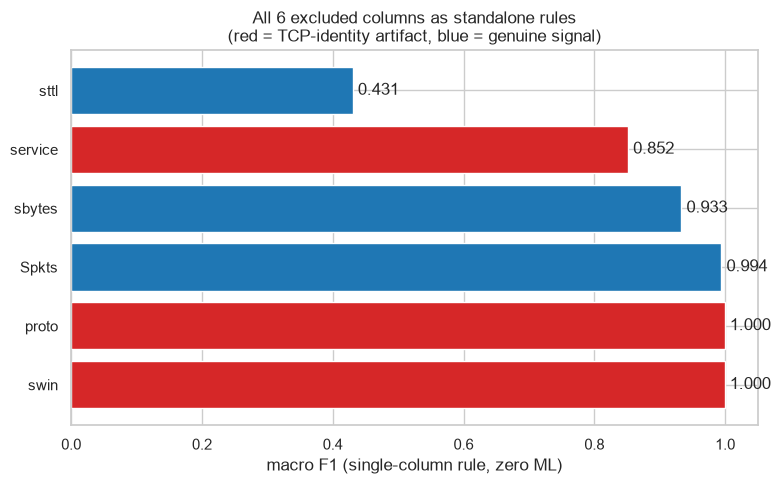

In [18]:
colors = ['#d62728' if c in ('swin', 'proto', 'service') else '#1f77b4' for c in rule_df.index]

plt.figure(figsize=(8, 5))
plt.barh(rule_df.index, rule_df['macro_f1'], color=colors)
plt.xlabel('macro F1 (single-column rule, zero ML)')
plt.title('All 6 excluded columns as standalone rules\n(red = TCP-identity artifact, blue = genuine signal)')
plt.xlim(0, 1.05)
for i, v in enumerate(rule_df['macro_f1']):
    plt.text(v, i, f' {v:.3f}', va='center')
plt.tight_layout()
plt.show()

`swin` and `proto` score highest (macro F1 ~0.9995) - but that's the TCP-identity artifact from 10a/10b showing up again, not a genuine network rule (it works here because this dataset can't measure loss on non-TCP traffic at all, not because non-TCP traffic is actually loss-free). `service` scores lower (~0.85) because its `none` category mixes both protocols together. Of the two **genuine** signals, `Spkts` (macro F1 0.994) clearly beats `sbytes` (macro F1 0.933), and both comfortably beat `sttl` (macro F1 0.431, barely better than chance).

**For a real pre-send shortcut rule (Stage 1 of the router simulation), `Spkts` is the only column on this list that is both strong and genuinely trustworthy** - the artifact columns would carry this dataset's TCP-measurement blind spot into the simulation as if it were a real fact, and `sttl`/`sbytes` are either too weak or redundant with `Spkts`.

## Section 11 - Final `X` and model family decision

**Excluded from `X` (stay in the file, excluded from modeling):**

| Column | Reason | Evidence |
|---|---|---|
| `swin` | TCP-identity leak | 0.999 correlation; 100%/0% split |
| `proto` | TCP-identity leak | ~100% loss on tcp, ~0% on everything else |
| `service` | TCP-identity leak (same root cause as `proto`) | UDP services ~0% loss, TCP services ~100% loss |
| `Spkts` | Single-feature dominance | bare threshold rule alone reaches ~0.97 macro F1 |
| `sbytes` | Single-feature dominance (correlated with `Spkts`) | adding it back inflates accuracy by double digits at fixed depth |
| `sttl` | Not dangerous, just not part of the chosen combination | low mutual information, confirmed not to inflate accuracy when added back |

**Final `X` - 10 columns:**
```python
final_feature_cols = [
    'smeansz', 'dst_port_bucket',
    'ct_state_ttl', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm',
    'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
]
```

**Model family, from the general-shape evidence (Sections 4-9):**
1. **Skew (Section 4):** every numeric candidate is right-skewed - tree-based models handle this natively.
2. **Outliers (Section 5):** extreme values carry real class signal, not noise - favors models robust to outliers.
3. **Multicollinearity (Section 6):** the `ct_*` counters correlate with each other by construction - a non-issue for trees, a real issue for linear coefficients.
4. **Linear separability (Section 7):** classes overlap in the PCA projection - a straight-line boundary is unlikely to work well.
5. **Categorical signal (Section 8):** `dst_port_bucket` swings meaningfully with loss rate - worth keeping.

**Decision: Random Forest and XGBoost**, `class_weight='balanced'`/`scale_pos_weight`, trained on the 10-column `final_feature_cols` above. Notebook 04 trains all 4 candidates (plus Logistic Regression and Decision Tree as simpler reference points) on this exact feature set, with tree depth and boosting rounds kept modest on the ensembles to control model complexity and reduce the risk of overfitting.